# TFM - EDA inicial 

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

from src.data.download import descargar_datos
from src.data.preprocessing import *

from src.features.basic_features import *

from src.utils.plotting import *
from src.utils.constants import *

### Definición del universo de activos
En esta sección se define el universo de activos financieros utilizado en el análisis. Este universo está compuesto por tres bloques diferenciados con el objetivo de capturar distintas dinámicas de mercado:

- Mercado español (España): acciones representativas del IBEX 35 y sectores clave de la economía española.
- Mercado estadounidense (USA): grandes compañías tecnológicas, financieras e industriales del S&P 500.
- ETFs sectoriales y de mercado: instrumentos que permiten capturar factores sistemáticos (tecnología, energía, value, momentum, etc.).

Esta combinación permite construir un dataset heterogéneo en términos de:

- geografía (Europa vs EE.UU.)
- sectores económicos
- exposición a factores de riesgo

In [2]:
TICKERS_TFM = {
    "spain": ["SAN.MC", "FER.MC", "ACS.MC", "ITX.MC", "REP.MC", "AMS.MC"],
    "usa"  : ["AAPL", "MSFT", "NVDA", "JPM", "BLK", "TSLA", "DPZ", "CAT", "XOM"],
    "etfs" : ["XLK", "SMH", "XLV", "XLI", "XLY", "XLP", "GLD", "SPY", 
              "QQQ", "EWP", "MTUM", "XLE", "XLF", "TLT", "XLU"]
}

ALL_TICKERS = [t for sublist in TICKERS_TFM.values() for t in sublist]

FECHA_INICIO = "2017-01-01"

### Justificación de la ventana temporal

El periodo de análisis comienza en 2017 con el objetivo de:

- Incluir distintos ciclos económicos completos
- Capturar periodos de alta volatilidad (COVID-19, inflación post-2021, etc.)
- Asegurar suficiente histórico para estimaciones de volatilidad y correlación

### Descarga de datos y estructura cruda del dataset

En esta fase se descargan los datos de mercado utilizando yfinance, obteniendo series temporales diarias de precios para todos los activos definidos en el universo de inversión.

La información descargada incluye cuatro variables principales:

- Close: precio de cierre ajustado (base del análisis)
- High: máximo diario
- Low: mínimo diario
- Volume: volumen de negociación

El objetivo de esta fase es trabajar con datos en su formato más crudo antes de cualquier transformación o limpieza, lo cual permite:

- Verificar la integridad de la descarga
- Detectar posibles valores nulos o huecos en el histórico
- Confirmar la estructura temporal y dimensional del dataset
- Asegurar consistencia entre activos

In [3]:
# 1. Descargar
data = descargar_datos(ALL_TICKERS, FECHA_INICIO)

# Ver estructura cruda
print(type(data))
print(data.keys())

print("\nClose shape:", data["close"].shape)
print(data["close"].head())

print("\nHigh shape:", data["high"].shape)
print(data["high"].head())


<class 'dict'>
dict_keys(['close', 'high', 'low', 'volume'])

Close shape: (2462, 30)
Ticker           AAPL     ACS.MC     AMS.MC         BLK        CAT  \
Date                                                                 
2017-01-02        NaN  17.578157  37.699169         NaN        NaN   
2017-01-03  26.721241  17.618322  37.764271  305.580566  76.283096   
2017-01-04  26.691324  17.360153  37.764271  305.762451  75.942230   
2017-01-05  26.827065  17.340073  38.085449  302.504517  75.479630   
2017-01-06  27.126141  17.363022  37.864098  303.896179  75.512077   

Ticker             DPZ        EWP     FER.MC         GLD     ITX.MC  ...  \
Date                                                                 ...   
2017-01-02         NaN        NaN  13.342505         NaN  24.104441  ...   
2017-01-03  141.719772  19.951918  13.714638  110.470001  23.864138  ...   
2017-01-04  145.863266  20.011364  13.637109  110.860001  23.638618  ...   
2017-01-05  145.666382  20.271446  13.80766

### Interpretación de la estructura obtenida

El objeto descargado es un diccionario de pandas DataFrames, donde cada clave representa una variable de mercado:

dict_keys(['close', 'high', 'low', 'volume'])

Cada DataFrame tiene la siguiente estructura:

- Filas: fechas (serie temporal diaria)
- Columnas: activos financieros (tickers)
- Valores: precios o volúmenes observados en mercado

### Dimensión del dataset
~2410 observaciones temporales
30 activos financieros
Panel balanceado parcialmente (presencia de NaNs en fechas iniciales)

### Observaciones importantes del EDA inicial

Del análisis visual de los datos crudos se observan varios aspectos relevantes:

##### Datos faltantes en el inicio de la serie

Algunos activos presentan valores NaN en los primeros días del dataset, lo cual es habitual debido a:

- Diferentes fechas de inicio de cotización
- Festivos o cierres de mercado
- Ajustes del proveedor de datos

##### Diferencias de escala entre activos

Los precios no son directamente comparables entre activos, lo que justifica:

- Necesidad de normalización posterior
- Uso de retornos en lugar de precios absolutos

##### Estructura adecuada para análisis panel

El formato actual permite:

- Transformación a formato largo (long format)
- Construcción de features por activo
- Aplicación de modelos de clustering multivariado

### Conclusión de esta fase

Esta etapa confirma que:

- El dataset es válido para análisis cuantitativo
- Existe heterogeneidad entre activos y mercados
- Es necesario un proceso de limpieza + transformación antes del EDA profundo


### Exploración inicial del dataset (EDA en crudo)

Antes de realizar cualquier transformación o limpieza, se realiza una exploración básica del dataset en su estado original. El objetivo de esta fase es validar la integridad global de los datos descargados y obtener una primera visión de su calidad.

En concreto, se analiza el número total de activos incluidos en el universo de estudio, el rango temporal completo de las series y la presencia de valores nulos en los precios de cierre por activo. Esta inspección inicial es clave para detectar posibles inconsistencias estructurales antes de proceder a la construcción de variables derivadas.

In [4]:
# ===============================
# EDA RAW (antes de transformar)
# ===============================

print("Número de activos:", len(ALL_TICKERS))

print("Rango temporal:")
print(data["close"].index.min(), "→", data["close"].index.max())

print("\nNaNs por activo (raw):")
print(data["close"].isna().sum().sort_values(ascending=False))

Número de activos: 30
Rango temporal:
2017-01-02 00:00:00 → 2026-07-14 00:00:00

NaNs por activo (raw):
Ticker
AAPL      69
BLK       69
DPZ       69
CAT       69
GLD       69
EWP       69
MTUM      69
NVDA      69
MSFT      69
JPM       69
SPY       69
TLT       69
SMH       69
QQQ       69
XLU       69
XLV       69
XLK       69
XLP       69
TSLA      69
XLE       69
XLI       69
XLF       69
XLY       69
XOM       69
ACS.MC    26
AMS.MC    26
FER.MC    26
ITX.MC    26
REP.MC    26
SAN.MC    26
dtype: int64


### Resultados del EDA en crudo

El universo de análisis está compuesto por 30 activos financieros, abarcando tanto acciones estadounidenses y europeas como ETFs representativos de distintos sectores y factores de mercado.

El periodo temporal cubre desde el 2 de enero de 2017 hasta el 1 de mayo de 2026, lo que proporciona una muestra suficientemente amplia para capturar distintos ciclos de mercado, incluyendo fases expansivas y periodos de alta volatilidad.

En cuanto a la calidad de los datos, se observan valores perdidos en todos los activos, aunque con un patrón muy claro. La mayoría de los activos estadounidenses y ETFs presentan aproximadamente 65 valores nulos, mientras que los activos españoles muestran alrededor de 26.

Este comportamiento es coherente con diferencias en las fechas de inicio de cotización o disponibilidad de datos en la fuente original. No obstante, estos valores nulos están concentrados al inicio de la serie y no afectan de forma significativa al periodo principal de análisis.

En conjunto, estos resultados confirman que el dataset presenta una estructura consistente y apta para análisis cuantitativo, aunque será necesario aplicar una limpieza inicial para garantizar la correcta alineación temporal de los activos.

### Construcción y preparación inicial del dataset

En esta fase se construye el dataset de trabajo a partir de las series temporales descargadas previamente. El proceso se compone de tres pasos consecutivos que permiten pasar de datos en bruto a un primer dataset analizable.

En primer lugar, se realiza la unificación de las distintas variables de mercado (precio de cierre, máximos, mínimos y volumen) en un único DataFrame en formato panel, donde cada fila representa un activo en una fecha concreta.

A continuación, se aplica una limpieza mínima con el objetivo de garantizar la consistencia estructural del dataset. Esta etapa incluye la eliminación de valores nulos críticos y la filtración de aquellos activos con un número insuficiente de observaciones, evitando así posibles sesgos en el análisis posterior.

Finalmente, se lleva a cabo una exploración exploratoria básica del dataset ya depurado, con el objetivo de evaluar su calidad, distribución de observaciones y características generales por activo.

Fecha         0
Ticker        0
Precio_Adj    0
High          0
Low           0
Volumen       0
dtype: int64


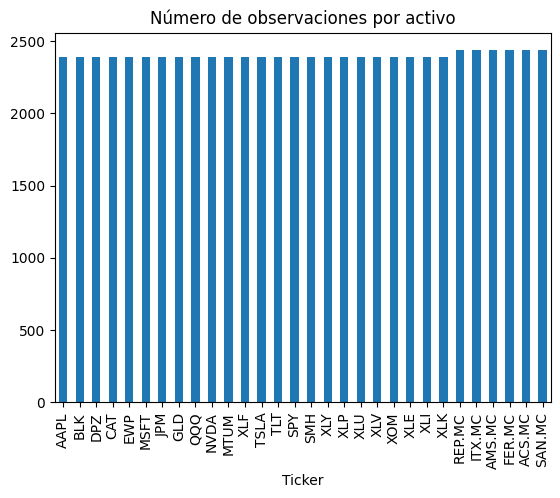

         count        mean         std         min         25%         50%  \
Ticker                                                                       
AAPL    2393.0  132.411620   76.712032   26.691324   49.691868  138.853378   
ACS.MC  2436.0   31.583238   23.822445    7.580558   18.814614   22.207959   
AMS.MC  2436.0   55.849511    8.176878   32.531433   50.308609   55.741915   
BLK     2393.0  630.449521  239.853324  282.151642  411.402710  617.066589   
CAT     2393.0  236.386159  174.344235   74.788391  118.767838  187.165176   
DPZ     2393.0  332.329126   96.233133  141.719772  253.397308  347.356689   
EWP     2393.0   27.406706    9.567507   14.837626   22.373047   24.123840   
FER.MC  2436.0   26.465533   12.214325   12.985877   17.747487   22.507253   
GLD     2393.0  190.719022   82.499163  110.470001  127.449997  169.210007   
ITX.MC  2436.0   29.139854   11.230651   16.191755   20.905308   24.119833   
JPM     2393.0  143.132584   72.358338   64.345604   88.678413  

In [5]:
# 2. Unificar
df = unificar_series_temporales(
    data["close"], data["high"], data["low"], data["volume"]
)

# 3. Limpieza mínima
df = drop_missing_basic(df)
df = filter_min_observations(df)

# 4. EDA básico
print(df.isna().sum())

plot_obs_per_ticker(df)

print(df.groupby("Ticker")["Precio_Adj"].describe())

### Caracterización inicial del dataset tras limpieza

Tras el proceso de unificación y limpieza, el dataset presenta una estructura homogénea en formato panel, lo que permite analizar de forma conjunta la evolución temporal de múltiples activos financieros.

El análisis descriptivo por activo revela una elevada heterogeneidad en términos de nivel de precios y volatilidad. Se observa una clara diferencia entre mercados, donde los activos estadounidenses tienden a presentar niveles de precio significativamente superiores en comparación con los activos europeos, mientras que los ETFs ocupan posiciones intermedias dentro del universo analizado.

En cuanto a la disponibilidad de datos, el número de observaciones por activo es relativamente equilibrado, aunque se aprecia una ligera mayor cobertura en los activos europeos con sufijo .MC. Esta diferencia sugiere posibles variaciones en la historia de cotización o en la calidad de la fuente de datos utilizada.

El análisis estadístico por activo confirma además la diversidad estructural del dataset, tanto en niveles medios de precio como en dispersión. Esta heterogeneidad es un resultado esperado en un universo que combina acciones individuales de distintos mercados con ETFs sectoriales y globales.

La visualización del número de observaciones por activo permite validar de forma visual esta distribución, confirmando que, aunque existen pequeñas diferencias entre activos, el conjunto de datos mantiene una cobertura suficientemente consistente para análisis posteriores.

## Validación estructural del dataset tras limpieza

Una vez construido y depurado el dataset, se realiza una inspección rápida de su estructura interna con el objetivo de verificar que las transformaciones aplicadas en etapas anteriores se han ejecutado correctamente.

En concreto, se revisan las primeras observaciones del DataFrame para confirmar la correcta unificación de variables y el formato final del dataset. Adicionalmente, se analiza la estructura general del objeto, incluyendo tipos de datos, número de registros y presencia de valores nulos.

Este paso no introduce nueva transformación sobre los datos, sino que actúa como una validación técnica del estado actual del dataset antes de continuar con el análisis exploratorio más profundo.

In [6]:
print(df.head())
print(df.info())

       Fecha Ticker  Precio_Adj       High        Low      Volumen
1 2017-01-03   AAPL   26.721241  26.762652  26.401460  115127600.0
2 2017-01-04   AAPL   26.691324  26.804054  26.629209   84472400.0
3 2017-01-05   AAPL   26.827065  26.884579  26.643017   88774400.0
4 2017-01-06   AAPL   27.126141  27.183655  26.794857  127007600.0
5 2017-01-09   AAPL   27.374596  27.475822  27.133036  134247600.0
<class 'pandas.DataFrame'>
Index: 72048 entries, 1 to 73858
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype        
---  ------      --------------  -----        
 0   Fecha       72048 non-null  datetime64[s]
 1   Ticker      72048 non-null  str          
 2   Precio_Adj  72048 non-null  float64      
 3   High        72048 non-null  float64      
 4   Low         72048 non-null  float64      
 5   Volumen     72048 non-null  float64      
dtypes: datetime64[s](1), float64(4), str(1)
memory usage: 4.1 MB
None


### Validación estructural del dataset tras limpieza

Una vez construido y depurado el dataset, se realiza una inspección rápida de su estructura interna con el objetivo de verificar que las transformaciones aplicadas en etapas anteriores se han ejecutado correctamente.

En concreto, se revisan las primeras observaciones del DataFrame para confirmar la correcta unificación de variables y el formato final del dataset. Adicionalmente, se analiza la estructura general del objeto, incluyendo tipos de datos, número de registros y presencia de valores nulos.

Este paso no introduce nueva transformación sobre los datos, sino que actúa como una validación técnica del estado actual del dataset antes de continuar con el análisis exploratorio más profundo.

## Construcción y análisis de retornos financieros

En esta fase se calcula el retorno diario de cada activo a partir de su precio ajustado. Los retornos representan la variación porcentual entre precios consecutivos y constituyen la variable fundamental en análisis cuantitativo, ya que permiten comparar activos de distintas escalas de precio de forma homogénea.

Una vez calculados los retornos, se realiza un análisis estadístico por activo con el objetivo de caracterizar su comportamiento dinámico en términos de rentabilidad y riesgo.

In [7]:
df = compute_returns(df)

stats = (
    df.groupby("Ticker")["Return"]
    .agg(["mean", "std", "skew", "kurt"])
    .sort_values("std", ascending=False)
)

print(stats)

            mean       std      skew       kurt
Ticker                                         
TSLA    0.002102  0.038027  0.294306   4.068258
NVDA    0.002326  0.031240  0.182313   5.186250
SMH     0.001429  0.021236 -0.080575   4.582734
SAN.MC  0.000726  0.020586  0.110336   7.373985
CAT     0.001244  0.019886 -0.017554   4.309338
ACS.MC  0.000970  0.019400  0.658662  24.216336
DPZ     0.000510  0.019229  0.885581  18.436947
REP.MC  0.000668  0.019090  0.326641  11.153860
AMS.MC  0.000285  0.018977  0.201435   8.863914
XLE     0.000512  0.018898 -0.491187  14.012452
AAPL    0.001207  0.018547  0.143092   6.757643
XOM     0.000532  0.018110 -0.013933   5.840061
BLK     0.000665  0.017687  0.088881   8.718428
JPM     0.000821  0.017457  0.314110  13.913417
MSFT    0.000963  0.017369  0.023086   7.333434
ITX.MC  0.000458  0.016388  0.364710   6.266331
XLK     0.001006  0.015917 -0.071594   8.558823
FER.MC  0.000696  0.014779 -0.209761   8.833434
QQQ     0.000877  0.014398 -0.192428   7

### Diferencias estructurales en riesgo y comportamiento de activos

El análisis de los retornos revela diferencias claras entre activos en términos de rentabilidad media, volatilidad y distribución estadística:

- Activos tecnológicos como TSLA y NVDA presentan:
    - mayor volatilidad (std elevada)
    - distribuciones más asimétricas
    - colas más pesadas (kurtosis elevada)
- Activos más defensivos o indexados como SPY, GLD o TLT muestran:
    - menor volatilidad
    - retornos más estables

Activos europeos como SAN.MC o REP.MC presentan comportamientos intermedios, aunque con cierta asimetría en sus distribuciones.

La kurtosis elevada en varios activos indica presencia de eventos extremos más frecuentes de lo que asumiría una distribución normal, lo cual es un hecho relevante para modelos de riesgo y clustering.

## Análisis de la distribución global de retornos

En esta celda se analiza la distribución completa de los retornos diarios del conjunto de activos, sin segmentación por ticker.

El objetivo es obtener una visión agregada del comportamiento del mercado, evaluando su media, dispersión y la presencia de valores extremos mediante cuantiles.

Este análisis complementa el estudio por activos individuales, proporcionando una visión global del riesgo del sistema financiero analizado.

In [8]:
df["Return"].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

count    72018.000000
mean         0.000782
std          0.017963
min         -0.210628
1%          -0.049161
5%          -0.025758
95%          0.026142
99%          0.051365
max          0.258464
Name: Return, dtype: float64

### Distribución no normal y presencia de eventos extremos

Los resultados muestran varias características relevantes:

La media de los retornos es ligeramente positiva, lo que refleja un crecimiento promedio muy bajo pero estable en el periodo analizado.
La desviación estándar es relativamente alta (≈ 1.8%), lo que indica variabilidad significativa diaria.
Los cuantiles extremos (1% y 99%) muestran que:
- existen caídas diarias cercanas al -5%
- y subidas superiores al +5%

Los valores mínimo y máximo confirman la presencia de eventos extremos puntuales, especialmente en periodos de alta volatilidad de mercado.


La distribución de retornos no sigue una normal perfecta, ya que presenta colas pesadas (fat tails), algo habitual en series financieras.

Esto justifica:

- el uso de métricas robustas
- la necesidad de modelos no gaussianos
- y la posterior utilidad de clustering para detectar regímenes de mercado

## Detección de eventos extremos en los retornos

En esta celda se identifican observaciones extremas del mercado filtrando aquellos retornos diarios cuya magnitud supera el 10% en valor absoluto.

El objetivo es aislar movimientos anómalos o de alta volatilidad para analizar episodios de estrés en los mercados financieros.

Estos eventos representan cambios bruscos de precio que pueden estar asociados a crisis financieras, anuncios macroeconómicos relevantes o shocks específicos de activos.

In [9]:
df.loc[df["Return"].abs() > 0.1].sort_values("Return")

,Fecha,Ticker,Precio_Adj,High,Low,Volumen,Return
50192,2020-09-08,TSLA,110.070000,122.913330,109.959999,3.463971e+08,-0.210628
52524,2020-03-09,XLE,12.991574,13.944699,12.911191,1.331138e+08,-0.201412
3287,2020-03-12,ACS.MC,10.961839,12.902514,10.932033,4.245957e+06,-0.188725
32491,2018-11-16,NVDA,4.067514,4.221626,3.997755,1.963520e+09,-0.187559
50067,2020-03-16,TSLA,29.671333,32.991333,29.478001,3.073425e+08,-0.185778
...,...,...,...,...,...,...,...
51259,2024-10-24,TSLA,260.480011,262.119995,242.649994,2.044919e+08,0.219190
51376,2025-04-09,TSLA,272.200012,274.690002,223.880005,2.194334e+08,0.226900
33658,2023-05-25,NVDA,37.902229,39.399158,36.559982,1.543911e+09,0.243696
13120,2020-02-20,DPZ,343.461426,351.469005,328.550719,5.009700e+06,0.256008


## Eventos extremos del mercado financiero

Los resultados muestran un conjunto reducido de observaciones (192 registros) que corresponden a movimientos diarios excepcionalmente grandes.

Se observan varios patrones relevantes:

Caídas extremas:
Marzo 2020 (COVID-19 crash) aparece repetidamente en múltiples activos
descensos superiores al -18% en algunos casos
Subidas extremas:
recuperaciones fuertes en activos tecnológicos como TSLA o NVDA
rebotes superiores al +20%

## Interpretación económica

Estos eventos no son errores ni ruido, sino:

episodios de crisis sistémica (ej. 2020)
alta volatilidad sectorial (tecnología)
shocks específicos de commodities o energía

## Análisis exploratorio avanzado del comportamiento de mercado

En esta fase se amplía el análisis exploratorio incorporando métricas derivadas y visualizaciones clave para comprender la dinámica conjunta de los activos financieros.

En concreto, se realiza:

- El cálculo de volatilidad para caracterizar la variabilidad de los activos
- El análisis de evolución temporal de precios normalizados
- La segmentación del comportamiento por grupos de activos (España, EE.UU. y ETFs)
- El estudio de la distribución de retornos
- El análisis de correlaciones entre activos financieros

El objetivo de esta fase es pasar de un análisis descriptivo individual a una visión sistémica del mercado.

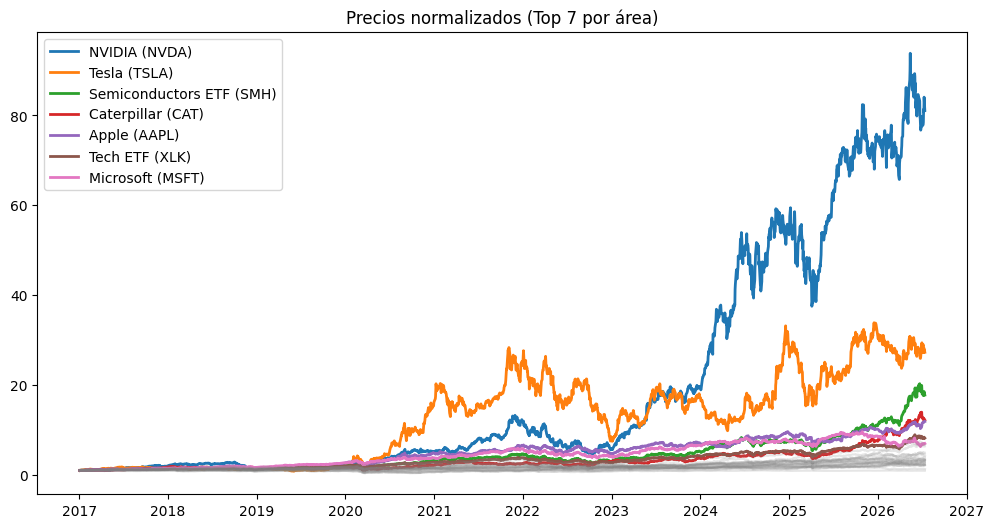

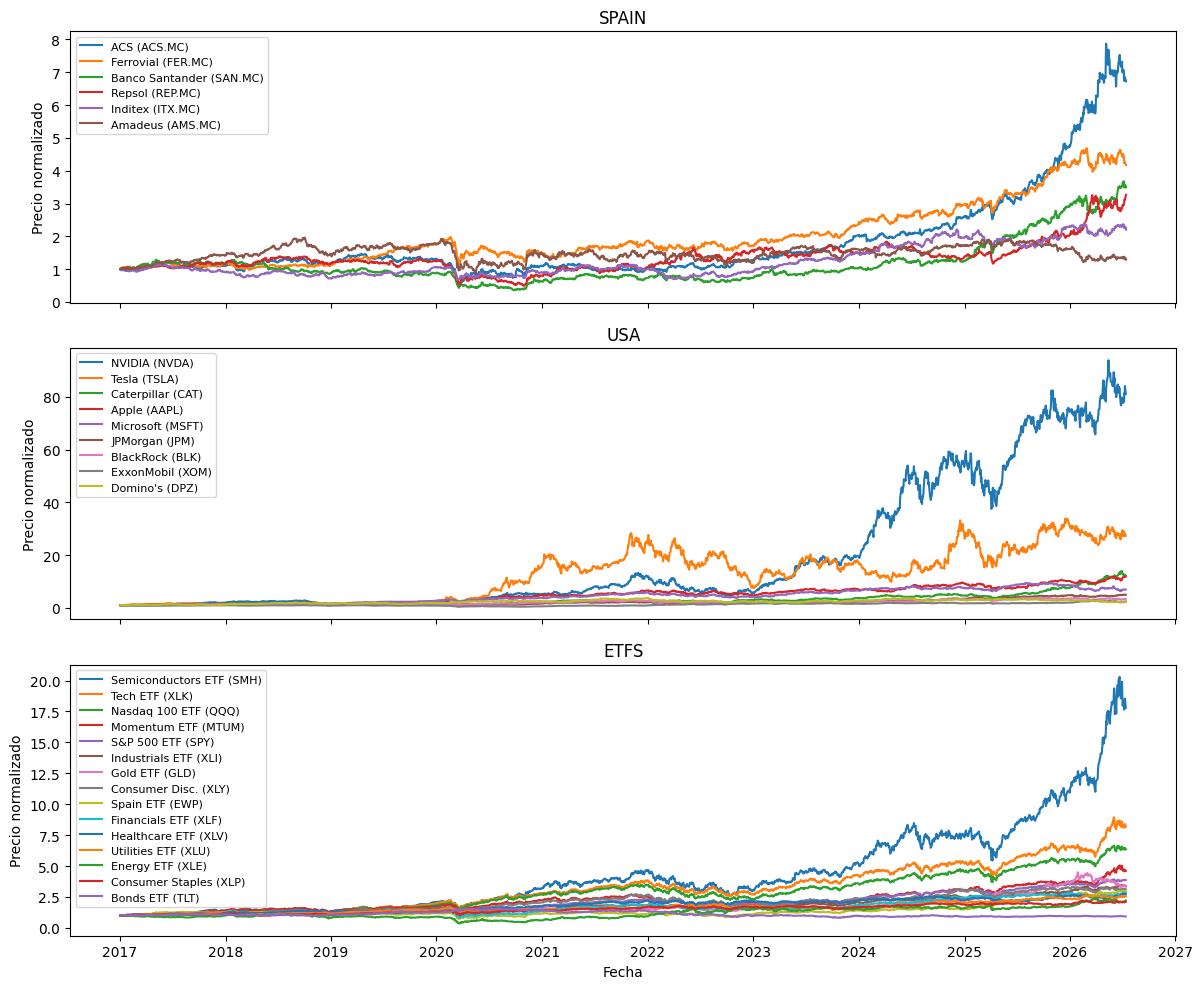

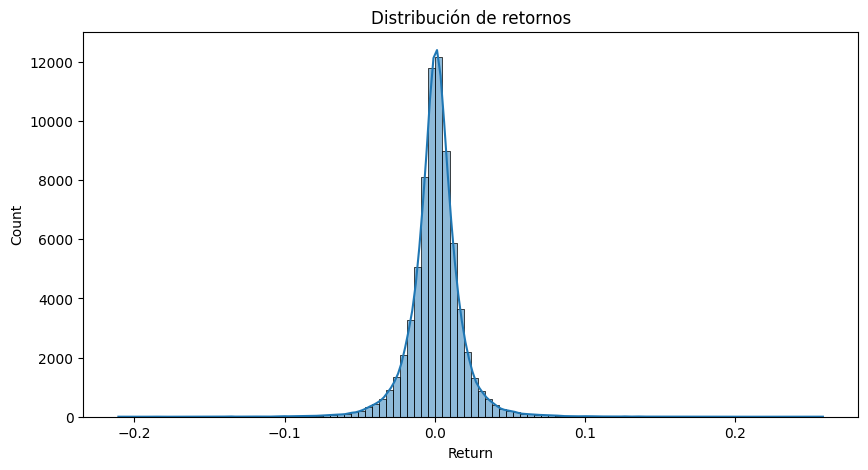

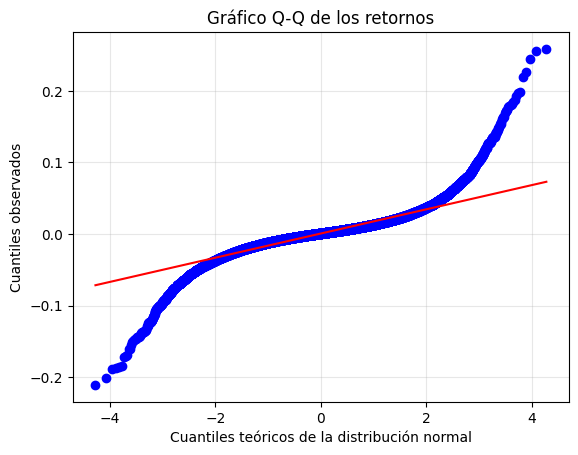

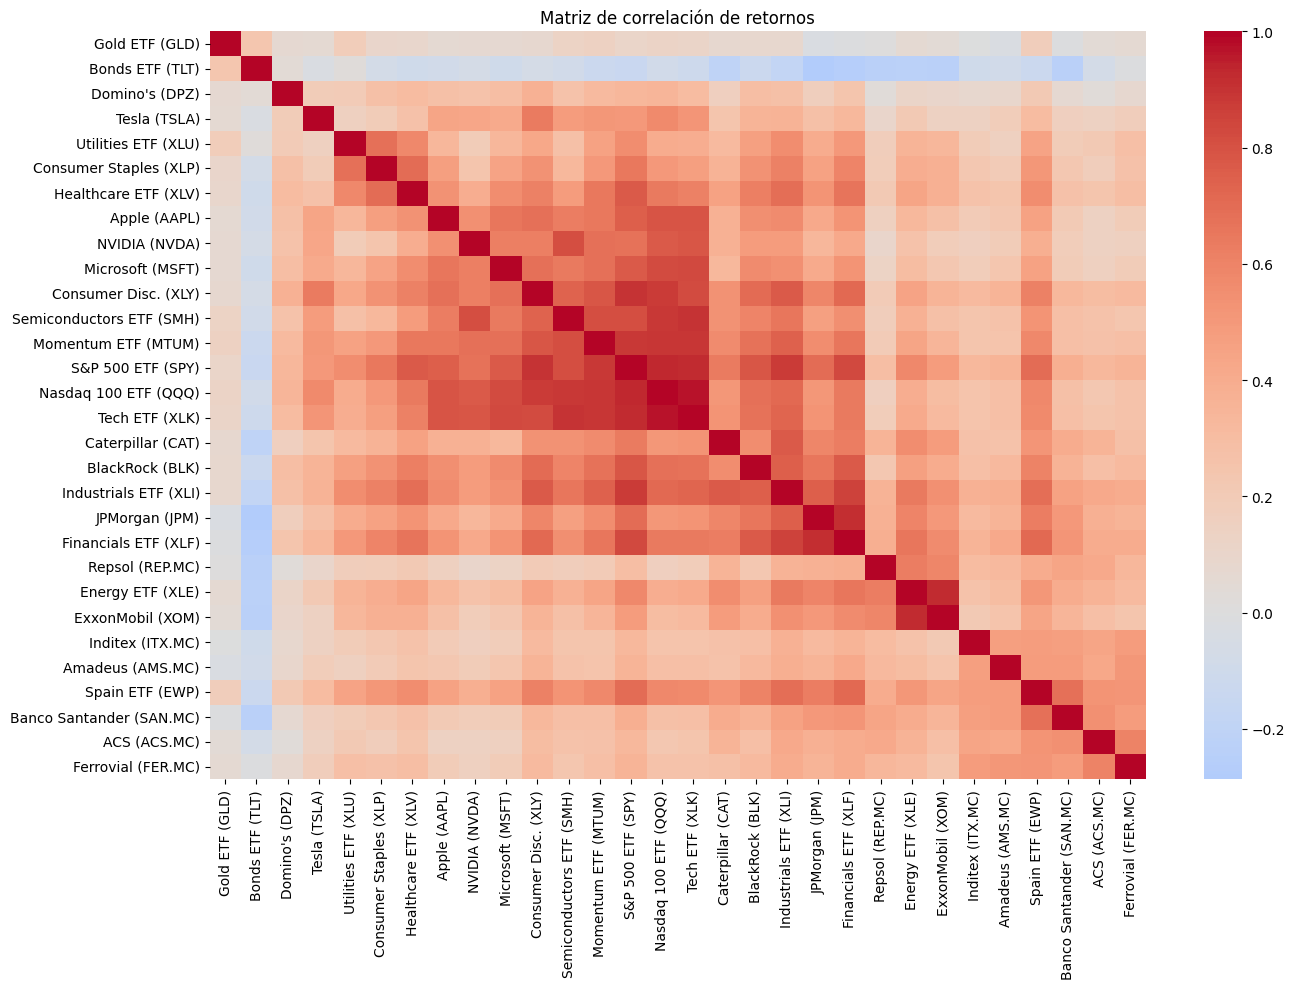

In [10]:
df = compute_volatility(df)

plot_normalized_prices(df, TICKER_NAMES, top_n=7)

plot_normalized_prices_by_group(df, TICKERS_TFM, TICKER_NAMES)

plot_returns_distribution(df)

plot_QQ_probplot(df)

corr = plot_correlation_matrix(df, TICKER_NAMES)

### Interpretación de resultados
### Evolución temporal y comportamiento de los activos

Las series temporales normalizadas muestran diferencias claras en el comportamiento de los activos:

- Destacan NVIDIA, Tesla y el ETF de semiconductores (SMH) como los activos con mayor revalorización acumulada, especialmente en la última parte del periodo.
- En el caso de los ETFs tecnológicos, se observa una tendencia similar, confirmando la concentración del crecimiento en el sector tecnológico.
- Se aprecia una caída generalizada en torno a 2020, asociada al shock del COVID-19, con un impacto más pronunciado en los activos europeos en comparación con los estadounidenses.

Cuando se separan los activos por regiones:

- España: destacan ACS y Ferrovial como los mejores comportamientos relativos dentro del grupo.
- EE.UU.: predominan claramente NVIDIA y Tesla como motores de crecimiento.
- ETFs sectoriales: el sector tecnológico y semiconductores lidera el rendimiento agregado.

### Distribución de retornos

La distribución de retornos presenta una forma aproximadamente simétrica con concentración alrededor de cero, lo que a primera vista podría sugerir normalidad.

Sin embargo, esto es engañoso: como se observó en análisis anteriores, la distribución presenta colas pesadas y eventos extremos, lo que implica desviaciones significativas respecto a una normalidad estricta.

Esto es característico de series financieras reales.

### Gráfico Q-Q

El gráfico Q-Q compara los cuantiles observados de los retornos con los cuantiles teóricos de una distribución normal. Si los datos siguieran una distribución gaussiana, los puntos se situarían aproximadamente sobre la recta de referencia. Las desviaciones observadas en los extremos indican una mayor frecuencia de eventos extremos de la esperada bajo hipótesis de normalidad, evidenciando la presencia de colas pesadas, fenómeno ampliamente documentado en los mercados financieros.

### Matriz de correlación

El análisis de correlaciones muestra estructuras interesantes entre activos:

- TLT (bonos a largo plazo) presenta baja correlación con la mayoría de activos, lo que confirma su rol como activo defensivo.
- GLD (oro) también muestra baja correlación general, actuando como activo refugio, aunque presenta cierta relación con TLT y algunos sectores defensivos como utilities.
- Sectores como tecnología y mercado estadounidense presentan correlaciones más elevadas entre sí, lo que sugiere comportamiento más sincronizado.

### Conclusión global

Esta fase del análisis permite identificar claramente:

- Concentración del rendimiento en sectores tecnológicos
- Presencia de activos defensivos con comportamiento independiente
- Efectos de crisis sistémicas (COVID-19) visibles en todos los grupos
- Estructuras de correlación útiles para clustering posterior